In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd


In [3]:
from tqdm import tqdm
import h5py

from multicam_tng.utils import convert_tng_mass

In [4]:
# hydro
subhalo_ids = []
stellar_mass = []
subhalo_mass_hydro = []

count = 0
for ii in tqdm(range(0, 448)):
    filename = f'../../data/tng100/fof_subhalo_tab_099.{ii}.hdf5'
    with h5py.File(filename, 'r') as f:

            

        if 'SubhaloMass' in f['Subhalo'].keys():
            for s in f['Subhalo']['SubhaloMass']:
                subhalo_ids.append(count)
                subhalo_mass_hydro.append(s)
                count+=1

            for s in f['Subhalo']['SubhaloMassInRadType'][:,4]: # 4 = star particles
                stellar_mass.append(s) 


subhalo_ids = np.array(subhalo_ids)
subhalo_mass = convert_tng_mass(np.array(subhalo_mass_hydro)) # log10(Msun / h)
stellar_mass = convert_tng_mass(np.array(stellar_mass)) # log10(Msun / h)
# group_mass = convert_tng_mass2(np.array(group_mass))
# hat_group_mass = convert_tng_mass2(np.array(hat_group_mass))

100%|██████████| 448/448 [00:06<00:00, 72.13it/s] 
/Users/imendoza/code/multicam-tng-mah/multicam_tng/utils.py:35: RuntimeWarning: divide by zero encountered in log10
  return np.where(gmass > 0, np.log10(gmass * 1e10 / TNG_H), 0)


In [5]:
smass = stellar_mass[stellar_mass > np.log10(1.4e6 * 100)]

(array([1.4206e+04, 1.1176e+04, 8.1300e+03, 5.1480e+03, 3.4350e+03,
        2.4500e+03, 8.3800e+02, 2.2200e+02, 6.1000e+01, 1.0000e+01]),
 array([ 8.14612961,  8.56987286,  8.99361515,  9.4173584 ,  9.84110165,
        10.26484489, 10.68858719, 11.11233044, 11.53607368, 11.95981598,
        12.38355923]),
 <BarContainer object of 10 artists>)

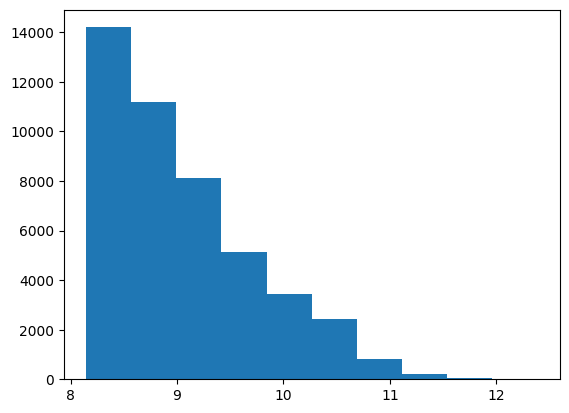

In [6]:
plt.hist(smass)

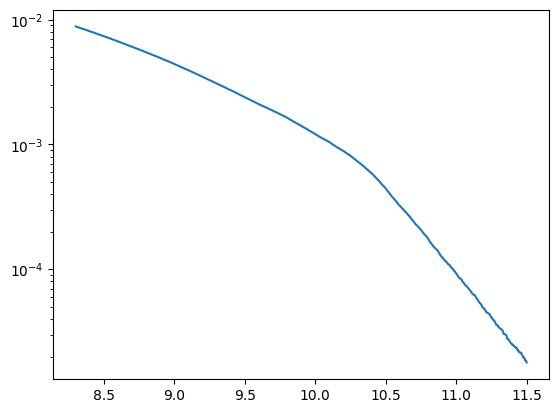

In [7]:
# stellar mass function 
x1 = 8.3
x2 = 11.5
bins = np.linspace(x1, x2, 1001)
nh = np.array([sum(smass > b) for b in bins])
smf = nh /  len(smass) / 100 # box

plt.semilogy(bins, smf)
# plt.yscale('log')

In [8]:
nh.min()

np.int64(82)

In [9]:
lf = np.vstack([bins, smf]).T
lf.shape

(1001, 2)

In [10]:
lf[:, 0], lf[:, 1]

(array([ 8.3   ,  8.3032,  8.3064, ..., 11.4936, 11.4968, 11.5   ],
       shape=(1001,)),
 array([8.81119187e-03, 8.78491987e-03, 8.75580173e-03, ...,
        1.86093353e-05, 1.83904020e-05, 1.79525352e-05], shape=(1001,)))

# Yao's code

In [11]:
import matplotlib.pyplot as plt
from AbundanceMatching import AbundanceFunction, LF_SCATTER_MULT, calc_number_densities, add_scatter, rematch


In [12]:
af = AbundanceFunction(lf[:,0], lf[:,1], ext_range=(x1, x2), 
                       faint_end_first=True, bright_end_fit_points=100)

/Users/imendoza/code/multicam-tng-mah/.venv/lib/python3.13/site-packages/AbundanceMatching/abundance_function.py:232: RuntimeWarning: invalid value encountered in divide
  phi_int = dphi/_diff(phi_log_new)*dx


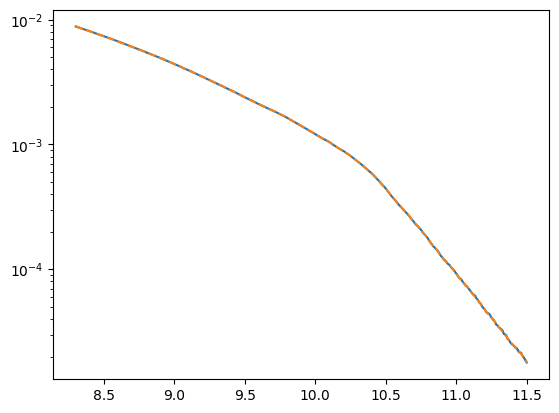

In [13]:
# check the abundance function
plt.semilogy(lf[:,0], lf[:,1])
x = np.linspace(x1, x2, 101)
plt.semilogy(x, af(x), ls='--') # fit

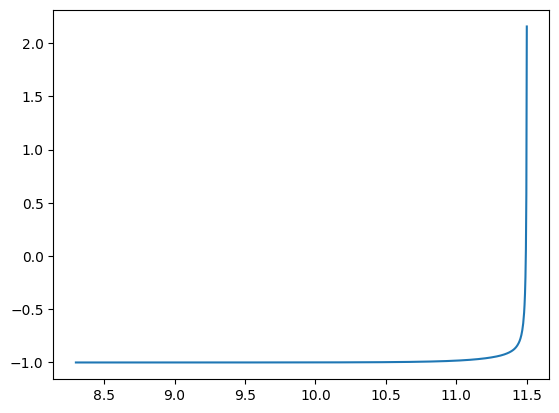

In [32]:
# deconvolution and check results (it's a good idea to always check this)
scatter = 0.2
remainder = af.deconvolute(scatter, repeat=41, sm_step=0.005)
x, nd = af.get_number_density_table()
plt.plot(x, remainder/nd);
# plt.axhline(1.0)

In [33]:
# get haloes
_file = "../../data/tng100_trees.npz"
with open(_file, 'rb') as fp:
    trees_data = np.load(fp)
    matches = trees_data['matches']
    bdmo = trees_data['bdmo']
    tdmo = trees_data['tdmo']
    bbar = trees_data['bbar']
    tbar = trees_data['tbar']
    
mask2 = (tdmo['ok'][:, -1]) & (tdmo['mdm'][:, -1] > 0) & (~bdmo['is_err'])
vpeak = bdmo['vpeak'][mask2]


In [34]:
# get number densities of the halo catalog
nd_halos = calc_number_densities(vpeak, 100.0)

In [35]:
catalog = af.match(nd_halos)

In [36]:
catalog_sc = af.match(nd_halos, scatter*LF_SCATTER_MULT)

In [45]:
np.isnan(catalog).sum(), np.isnan(catalog_sc).sum(), catalog.shape - np.isnan(catalog).sum()

(np.int64(526078), np.int64(526078), array([7596]))

In [42]:
np.sum((smass > x1) & (smass < x2))

np.int64(40164)

In [38]:
# plt.hist(catalog)

In [51]:
bins

array([ 8.30002089,  8.45014615,  8.60027142,  8.75039668,  8.90052194,
        9.0506472 ,  9.20077246,  9.35089772,  9.50102298,  9.65114824,
        9.8012735 ,  9.95139876, 10.10152402, 10.25164928, 10.40177454,
       10.55189981, 10.70202507, 10.85215033, 11.00227559, 11.15240085,
       11.30252611, 11.45265137])

(array([0.84352638, 0.76156296, 0.70946475, 0.63115152, 0.58187392,
        0.50820639, 0.45146249, 0.383768  , 0.30777762, 0.26165246,
        0.25103372, 0.19661266, 0.17819578, 0.16807479, 0.1597789 ,
        0.10336682, 0.06835816, 0.0418113 , 0.02654686, 0.01742137,
        0.00945732]),
 array([ 8.30002089,  8.45014615,  8.60027142,  8.75039668,  8.90052194,
         9.0506472 ,  9.20077246,  9.35089772,  9.50102298,  9.65114824,
         9.8012735 ,  9.95139876, 10.10152402, 10.25164928, 10.40177454,
        10.55189981, 10.70202507, 10.85215033, 11.00227559, 11.15240085,
        11.30252611, 11.45265137]),
 [<matplotlib.patches.Polygon at 0x1120da210>])

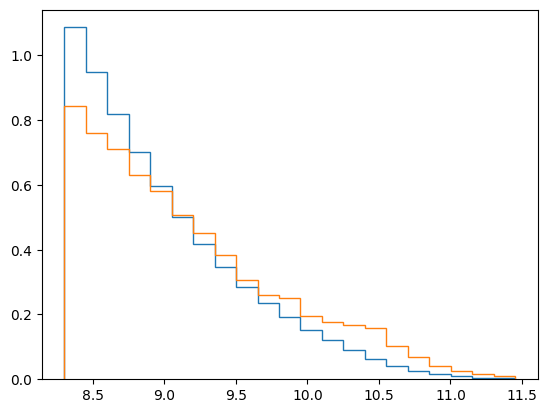

In [66]:
mask = ~np.isnan(catalog_sc)

mask_ = (smass > x1) & ( smass < x2)
_, bins, _ = plt.hist(catalog_sc[mask], bins=21, histtype='step', density=True)
plt.hist(smass[mask_], bins=bins, density=True, histtype='step')


In [60]:
x2

11.5

(array([7.69372238e-01, 7.03512846e-01, 6.32770962e-01, 5.47487514e-01,
        4.80328712e-01, 3.99170845e-01, 3.25282466e-01, 2.43907600e-01,
        2.18518642e-01, 1.72188404e-01, 1.48970256e-01, 1.37469274e-01,
        8.08323674e-02, 4.55699252e-02, 2.39784607e-02, 1.30199786e-02,
        6.72698897e-03, 4.33999288e-03, 1.41049102e-03, 7.59498754e-04,
        2.16999644e-04]),
 array([ 8.14612961,  8.34791183,  8.54969406,  8.75147629,  8.95325947,
         9.15504169,  9.35682392,  9.55860615,  9.76038837,  9.9621706 ,
        10.16395378, 10.36573601, 10.56751823, 10.76930046, 10.97108269,
        11.17286491, 11.37464714, 11.57642937, 11.77821159, 11.97999477,
        12.181777  , 12.38355923]),
 [<matplotlib.patches.Polygon at 0x12270efd0>])

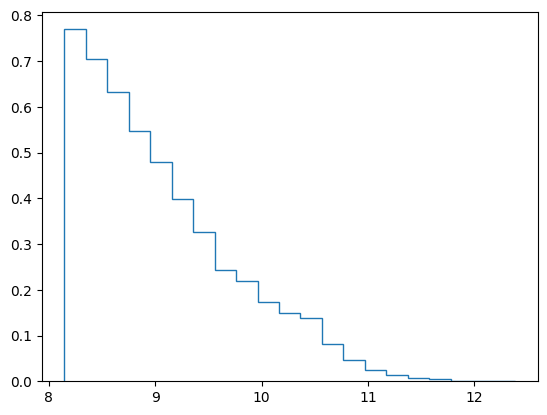